In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("subhaditya/fer2013plus")

print("Path to dataset files:", path)

Path to dataset files: /home/omarhammad/.cache/kagglehub/datasets/subhaditya/fer2013plus/versions/1


In [27]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Define data transformations
data_transforms = {
    "train": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Convert RGB to Grayscale
        transforms.Resize((48, 48)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # For grayscale, single channel mean/std
    ]),
    "test": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Convert RGB to Grayscale
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
}


# Paths to dataset
train_dir = path + "/fer2013plus/fer2013/train" 
test_dir = path + "/fer2013plus/fer2013/test" 

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms["train"])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms["test"])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Train loader and test loader created!")


# Check a sample batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)


# Get class-to-label mapping
class_names = train_dataset.classes
print("Class Names:", class_names)

# Example: label 0 corresponds to the first class
print("Label 0 is:", class_names[0])



Train loader and test loader created!
Image batch shape: torch.Size([4, 1, 48, 48])
Labels batch shape: torch.Size([4])
Labels: tensor([7, 0, 5, 7])
Class Names: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Label 0 is: anger


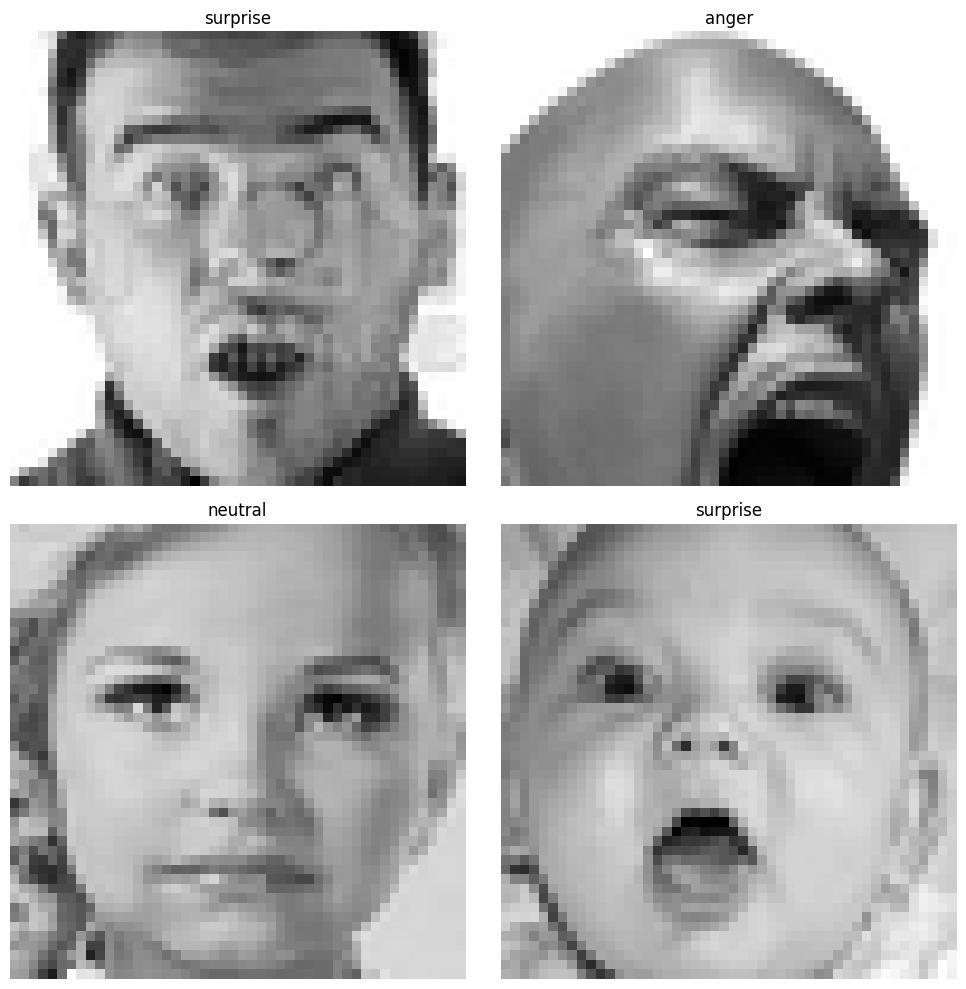

In [28]:
import matplotlib.pyplot as plt

def plot_image_batch(images, labels, class_names):
    """
    Plots a batch of images with their corresponding labels.

    Args:
        images (Tensor): A batch of images (shape: [batch_size, channels, height, width]).
        labels (Tensor): Corresponding labels for the images.
        class_names (list): List of class names corresponding to the labels.
    """

    images = images.permute(0, 2, 3, 1).numpy() 


    images = images * 0.5 + 0.5  


    batch_size = images.shape[0]
    grid_size = int(batch_size ** 0.5) 
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        if i < batch_size:

            ax.imshow(images[i].squeeze(), cmap="gray" if images[i].shape[-1] == 1 else None)

            ax.set_title(class_names[labels[i]])
            ax.axis("off")
        else:

            ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_image_batch(images, labels, class_names)


In [29]:
import torch.nn.functional as F
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)  # Grayscale
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(in_features=64 * 12 * 12, out_features=128)  # Adjusted for 48x48 input
        self.fc2 = nn.Linear(in_features=128, out_features=8)  # 8 emotion classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Activation after conv1 + pooling
        x = self.pool(F.relu(self.conv2(x)))  # Activation after conv2 + pooling
        x = x.view(-1, 64 * 12 * 12)  # Flatten tensor for fully connected layers
        x = F.relu(self.fc1(x))  # Fully connected layer 1 with activation
        x = self.fc2(x)  # Output layer
        return x


model = CNN()


In [30]:
import torch.optim as optim

# Step 4: Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.SGD(model.parameters(), lr=0.001)  # call optimizer

In [ ]:
# Step 5: Train the Model
num_epochs = 2  # define number of epochs
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i + 1) % 100 == 0:  # Print every 100 batches
            print(
                f"Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {running_loss / 100:.4f}")
            running_loss = 0.0

Epoch [1/2], Step [100/7097], Loss: 1.9544
Epoch [1/2], Step [200/7097], Loss: 1.7491
Epoch [1/2], Step [300/7097], Loss: 1.7134
Epoch [1/2], Step [400/7097], Loss: 1.6306
Epoch [1/2], Step [500/7097], Loss: 1.5876
Epoch [1/2], Step [600/7097], Loss: 1.5897
Epoch [1/2], Step [700/7097], Loss: 1.6380
Epoch [1/2], Step [800/7097], Loss: 1.6238
Epoch [1/2], Step [900/7097], Loss: 1.5593
Epoch [1/2], Step [1000/7097], Loss: 1.5764
Epoch [1/2], Step [1100/7097], Loss: 1.5698
Epoch [1/2], Step [1200/7097], Loss: 1.5593
Epoch [1/2], Step [1300/7097], Loss: 1.5929
Epoch [1/2], Step [1400/7097], Loss: 1.5478
Epoch [1/2], Step [1500/7097], Loss: 1.5650
Epoch [1/2], Step [1600/7097], Loss: 1.5897
Epoch [1/2], Step [1700/7097], Loss: 1.6163
Epoch [1/2], Step [1800/7097], Loss: 1.5476
Epoch [1/2], Step [1900/7097], Loss: 1.6478
Epoch [1/2], Step [2000/7097], Loss: 1.5239
Epoch [1/2], Step [2100/7097], Loss: 1.5434
Epoch [1/2], Step [2200/7097], Loss: 1.5483
Epoch [1/2], Step [2300/7097], Loss: 1.50

In [21]:
import torch

# Step 6: Evaluate the Model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {correct / total:.4f}")

Test Accuracy: 0.3664


In [ ]:
torch.save(model.state_dict(), 'cnn_model.pth')


In [22]:
# Prepare to count predictions for each class
classes = train_dataset.classes  # Get class names from the dataset
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# Disable gradients for evaluation
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = model(images)  # Replace 'net' with your model name, e.g., 'model'
        _, predictions = torch.max(outputs, 1)  # Get predicted class indices

        # Collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            label_name = classes[label]  # Convert label index to class name
            if label == prediction:
                correct_pred[label_name] += 1
            total_pred[label_name] += 1

# Print accuracy for each class
for classname, correct_count in correct_pred.items():
    if total_pred[classname] > 0:  # Avoid division by zero
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:10s} is {accuracy:.1f} %')
    else:
        print(f'No predictions for class: {classname}')


Accuracy for class: anger      is 0.0 %
Accuracy for class: contempt   is 0.0 %
Accuracy for class: disgust    is 0.0 %
Accuracy for class: fear       is 0.0 %
Accuracy for class: happiness  is 0.1 %
Accuracy for class: neutral    is 99.9 %
Accuracy for class: sadness    is 0.0 %
Accuracy for class: surprise   is 0.6 %


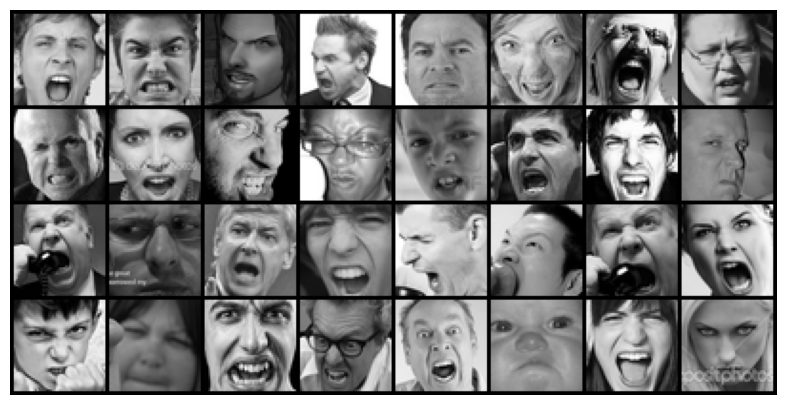

GroundTruth:  anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger anger


In [25]:
from matplotlib.pyplot import imshow
import torchvision
import matplotlib.pyplot as plt

# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Display images
fig, ax = plt.subplots(figsize=(10, 5))  # Adjust figure size for better display
imshow(torchvision.utils.make_grid(images, normalize=True).permute(1, 2, 0))  # Normalize and permute for correct display
plt.axis('off')  # Hide axes
plt.show()

# Print GroundTruth labels
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(len(labels))))
